# 🔐 NeMo Safe Synthesizer Tutorial: Downstream Task Utility

#### What you'll learn

This notebook evaluates how useful synthetic data is for a downstream binary classification task. We compare two logistic regression models: one trained on real data and one trained on synthetic data.

The workflow is:
1. Load telco churn data and build a deterministic 8,000/2,000 train-holdout split.
2. Train Safe Synthesizer on the 8,000 real training rows.
3. Generate 8,000 synthetic training rows.
4. Train two identical ML pipelines (real-trained vs synthetic-trained).
5. Evaluate both models on the same 2,000-row real holdout set.

### 🖥️ Prerequisites

This notebook requires a Linux machine with an NVIDIA GPU (H100 recommended, A100 minimum) and CUDA 12.9+. It will not run on macOS, Windows, or Apple Silicon.

### ⚡ Install dependencies

Run the cell below to install NeMo Safe Synthesizer (engine + CUDA 12.9) and the Python packages used for downstream model training and evaluation.

In [1]:
%%capture
# SPDX-FileCopyrightText: Copyright (c) 2025-2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# SPDX-License-Identifier: Apache-2.0

%pip install -U "nemo-safe-synthesizer[engine,cu129]"
%pip install scikit-learn pandas

### 🔑 Set the inference API key for PII column classification

NeMo Safe Synthesizer uses an LLM-based classifier to infer potential PII columns. To enable this, set `NSS_INFERENCE_KEY` (you can create one at [build.nvidia.com](https://build.nvidia.com/settings/api-keys)).

Setting this value is optional, but strongly recommended for better PII handling quality.

In [2]:
import getpass
import os

if "NSS_INFERENCE_KEY" not in os.environ:
    os.environ["NSS_INFERENCE_KEY"] = getpass.getpass("Paste inference API key (or press Enter to skip): ")

print("NSS_INFERENCE_KEY is set" if os.environ.get("NSS_INFERENCE_KEY") else "NSS_INFERENCE_KEY is not set")

NSS_INFERENCE_KEY is set


In [3]:
os.environ["NIM_MODEL_ID"] = "qwen/qwen3-next-80b-a3b-instruct"

### 📥 Load telco dataset and create train/holdout split

Load the telco churn dataset from CSV, then create a deterministic 10,000-row subset for this tutorial.

From this subset:
- 8,000 rows are used as the real training source for Safe Synthesizer and the real-trained baseline model.
- 2,000 rows are held out as a fixed evaluation set shared by both downstream models.

The target label is `Churn Label`.

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = Path("telco_churn_DD_0526.csv")
TARGET = "Churn Label"
SEED = 42

full_df = pd.read_csv(DATA_PATH)

# tmp: change NaN to None for Churn Reason
full_df["Churn Reason"] = full_df["Churn Reason"].where(full_df["Churn Reason"].notna(), None)

train_real_df, holdout_df = train_test_split(
    full_df, test_size=2000, random_state=SEED, shuffle=True
)
train_real_df = train_real_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

print(f"Train rows: {len(train_real_df)}")
print(f"Holdout rows: {len(holdout_df)}")

Train rows: 8000
Holdout rows: 2000


### ⚙️ Train Safe Synthesizer and generate synthetic training data

Create a `SafeSynthesizer` builder with the 8,000-row real training split, then run the full synthesis pipeline.

In this notebook, generation is configured to produce exactly 8,000 synthetic rows so the synthetic-trained model and real-trained model use the same training set size.

In [5]:
from nemo_safe_synthesizer.sdk.library_builder import SafeSynthesizer

builder = SafeSynthesizer().with_data_source(train_real_df).with_train(num_input_records_to_sample=10000).with_generate(num_records=8000)
builder.run()
results = builder.results
synth_df = results.synthetic_data

print(f"Synthetic rows: {len(synth_df)}")
synth_df.head()

2026-05-29T14:39:09.518 | Nemo Safe Synthesizer |  user    |  info  |  orchestrator.py: 196 
Preflight: 8 check(s) ran, 0 skipped — 0 error(s), 3 warning(s)
2026-05-29T14:39:09.782 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Estimated max token count for examples in dataset - this is used to determine the rope scaling factor: 471.625
2026-05-29T14:39:09.783 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Parameter `rope_scaling_factor` was automatically set to 1 based on an estimated token count given the lengths of each training record and the column names.
2026-05-29T14:39:09.783 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
`learning_rate` was automatically set to 0.0005 with pretrained_model='HuggingFaceTB/SmolLM3-3B'.


/root/Safe-Synthesizer/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

2026-05-29T14:39:09.870 | Nemo Safe Synthesizer |  runtime |  info  |  model.py: 3185 
Loading the following GLiNER type: <class 'gliner.model.UniEncoderSpanGLiNER'>...
2026-05-29T14:39:14.663 | Nemo Safe Synthesizer |  runtime |  info  |  nemo_pii.py: 118 
PII column classification will call the default NVIDIA inference API at https://integrate.api.nvidia.com/v1. To use another server, set the NSS_INFERENCE_ENDPOINT environment variable to a NIM/OpenAI-compatible endpoint.
2026-05-29T14:39:29.118 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
LLM column classification took 14.327736038714647 seconds. 
2026-05-29T14:39:29.189 | Nemo Safe Synthesizer |  user    |  info  |  edit.py: 719 
Executing transform step : 0 / 1


               Transformation Progress                
+----------------------------------------------------+
| Metric         | Value                             |
|----------------+-----------------------------------|
| Transform Time | 13.8 seconds                      |
| Step           | 1 of 1                            |
| Rule           | 3 of 11                           |
| Column         | "Name", #7 of 31                  |
| Progress       | 7600 rows out of 7600 transformed |
| Speed          | 🐇 550.5 rows per second.         |
+----------------------------------------------------+

...

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

2026-05-29T14:55:38.342 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
2026-05-29T14:55:39.441 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Evaluation complete.
2026-05-29T14:55:44.277 | Nemo Safe Synthesizer |  runtime |  info  |  library_builder.py: SafeSynthesizer.run: 528 
Entering SafeSynthesizer.save_results
2026-05-29T14:55:44.334 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Saved synthetic data to safe-synthesizer-artifacts/default---data/2026-05-29T14:39:09/generate/synthetic_data.csv
2026-05-29T14:55:44.335 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Saved evaluation report to safe-synthesizer-artifacts/default---data/2026-05-29T14:39:09/generate/evaluation_report.html
2026-05-29T14:55:44.336 | Nemo Safe Synthesizer |  runtime |  info  |  observability.py: 652 
Saved evaluation metrics and runtimes to safe-synthesizer-artifacts/default---data/2026-05-29T14:39:09/generate/evaluat

,CustomerID,Count,Country,State,City,Zip Code,Name,Gender,Age,Partner,...,Tech Support,Streaming TV,Streaming Movies,Monthly Charge,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,CUST-0A9C9CDF,1,United States,Rhode Island,Lake Eric,94881,Stephanie Scott,Female,22,Yes,...,Yes,Yes,No,118.43,710.58,No,0,47,3256,Dawn Cruz
1,CUST-5B8C3E7D,1,United States,California,Yamahaton,35454,Steven Reyes,Female,60,Yes,...,Yes,No,Yes,85.43,85.43,No,0,54,3248,Dawn Cruz
2,CUST-7592BB4E,1,United States,Rhode Island,Oliviaborough,26090,Jennifer Sullivan,Female,37,Yes,...,Yes,No,Yes,124.11,8826.81,No,0,17,6773,Dawn Cruz
3,CUST-B2D2ED3C,1,United States,Rhode Island,Allenhaven,19159,Randy Morales,Male,24,Yes,...,No,Yes,No,86.81,0.00,No,0,74,3656,Dawn Cruz
4,CUST-5FAC89EE,1,United States,Louisiana,Allenstad,4845,Samantha Capps,Male,64,Yes,...,Yes,No,Yes,90.00,2610.00,No,0,10,4540,Dawn Cruz


### 🤖 Train two downstream logistic regression models

To ensure a fair utility comparison, both models use the same preprocessing and architecture:
- one model is trained on real 8,000-row training data,
- one model is trained on synthetic 8,000-row training data.

Both are evaluated on the same real 2,000-row holdout split.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DROP_COLUMNS = [
    "CustomerID",
    "Name",
    "Zip Code",
    "City",
    "State",
    "Country",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "Count",
    "Total Charges",
]

def make_xy(df: pd.DataFrame):
    y = (df[TARGET] == "Yes").astype(int)
    x = df.drop(columns=DROP_COLUMNS + [TARGET], errors="ignore")
    return x, y

def build_model(feature_df: pd.DataFrame):
    cat_cols = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in feature_df.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                cat_cols,
            ),
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ]
    )

    return Pipeline(
        steps=[
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=5000, random_state=SEED)),
        ]
    )

x_train_real, y_train_real = make_xy(train_real_df)
x_train_synth, y_train_synth = make_xy(synth_df)
x_holdout, y_holdout = make_xy(holdout_df)

real_model = build_model(x_train_real).fit(x_train_real, y_train_real)
synth_model = build_model(x_train_synth).fit(x_train_synth, y_train_synth)

In [21]:
def evaluate_model(name, model, x_eval, y_eval):
    y_pred = model.predict(x_eval)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_eval, y_pred, average="binary", zero_division=0
    )
    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": confusion_matrix(y_eval, y_pred).tolist(),
    }

real_metrics = evaluate_model("Trained on real 8k", real_model, x_holdout, y_holdout)
synth_metrics = evaluate_model("Trained on synthetic 8k", synth_model, x_holdout, y_holdout)

comparison_df = pd.DataFrame([real_metrics, synth_metrics]).set_index("model")
display(comparison_df[["accuracy", "precision", "recall", "f1"]].round(4))

print("Confusion matrices:")
print(f"Real model:  {real_metrics['confusion_matrix']}")
print(f"Synth model: {synth_metrics['confusion_matrix']}")

,accuracy,precision,recall,f1
model,,,,
Trained on real 8k,0.8660,0.6299,0.2658,0.3738
Trained on synthetic 8k,0.8655,0.6702,0.2093,0.3190


Confusion matrices:
Real model:  [[1652, 47], [221, 80]]
Synth model: [[1668, 31], [238, 63]]


### 📊 Interpret downstream utility results

Compare the holdout metrics (accuracy, precision, recall, and F1) from both models.

If the synthetic-trained model is close to the real-trained baseline, the synthetic dataset preserves meaningful predictive signal for this task. Larger metric gaps indicate utility loss for downstream training.

In [8]:
# Synthetic data and evaluation artifacts are automatically saved to the run directory.
print(f"Artifacts saved to: {builder._workdir.generate.path}")

Artifacts saved to: safe-synthesizer-artifacts/default---data/2026-05-29T14:39:09/generate


### 🧭 Compare learned logistic coefficients vs simulation coefficients

This compares coefficients for terms that are directly mappable to one-hot/binary features in the current model pipeline.

Note: simulation terms based on thresholds/interactions (`tenure` buckets, `monthly` buckets, `age` buckets, `services`, `fiber_outage_pressure`, `autopay`) are not directly one-to-one with the current linear feature set and are listed separately.

,feature,term,simulation_coef,real_model_coef,synthetic_model_coef
0,cat__Contract_Month-to-Month,Contract: Month-to-Month,1.15,1.0964,1.1113
2,cat__Contract_Two Year,Contract: Two Year,-0.95,-0.8297,-0.7377
3,cat__Internet Service_Fiber Optic,Internet: Fiber Optic,0.55,0.5591,0.5376
4,cat__Tech Support_No,Tech Support: No,0.55,0.1159,0.2112
1,cat__Contract_One Year,Contract: One Year,-0.45,-0.5408,-0.5587
7,cat__Payment Method_Mailed Check,Payment: Mailed Check,0.35,0.3611,0.2260
9,cat__Payment Method_Credit Card,Payment: Credit Card,-0.35,-0.3509,-0.2935
8,cat__Payment Method_Bank Withdrawal,Payment: Bank Withdrawal,-0.35,-0.2843,-0.1177
11,cat__Dependents_Yes,Dependents: Yes,-0.35,-0.3109,-0.2728
5,cat__Online Security_No,Online Security: No,0.25,0.0198,-0.0469


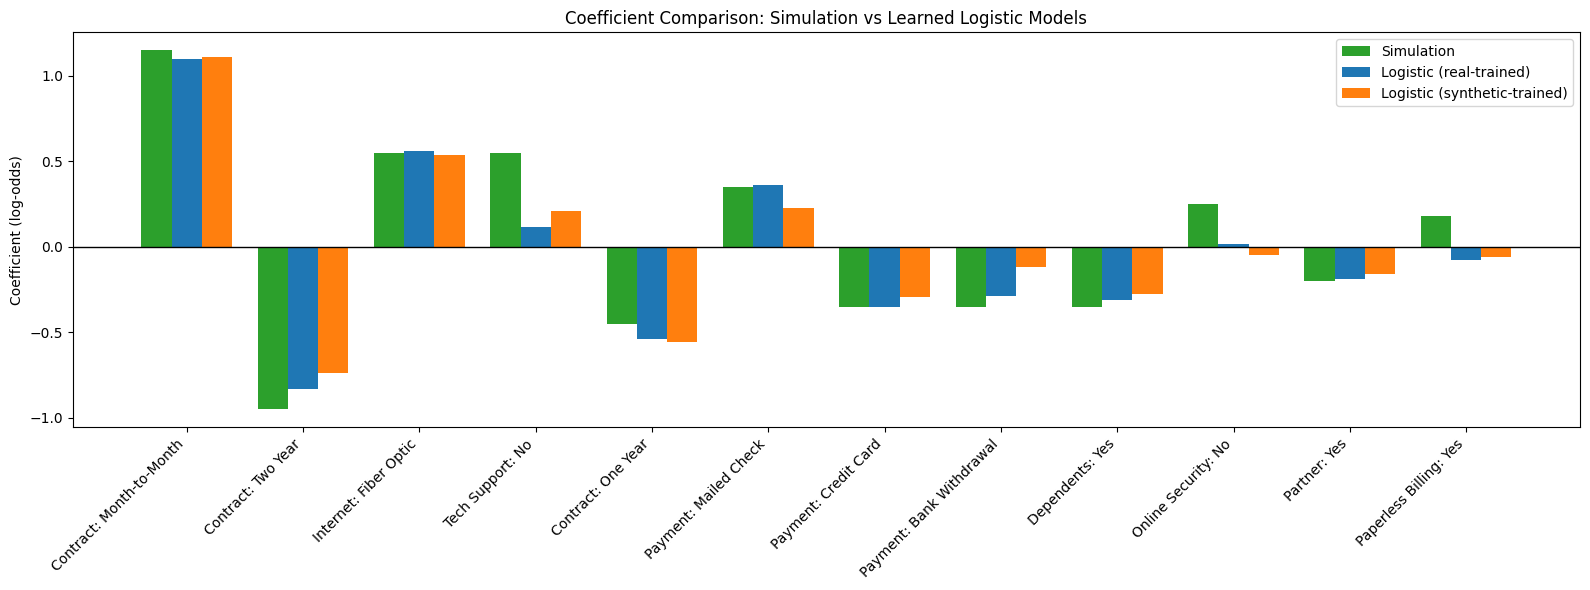

Not directly comparable (nonlinear/interaction simulation terms):
- tenure buckets (<=6, <=12, >=24, >=48)
- monthly charge buckets (>=80, >=95)
- age buckets (<=25, >=65)
- services bundle count buckets (>=3, >=5)
- fiber_outage_pressure global effect
- autopay interaction term


In [22]:
import matplotlib.pyplot as plt
import numpy as np


def get_logistic_coef_series(model):
    feature_names = model.named_steps["prep"].get_feature_names_out()
    coefs = model.named_steps["clf"].coef_.ravel()
    return pd.Series(coefs, index=feature_names)


real_coef_series = get_logistic_coef_series(real_model)
synth_coef_series = get_logistic_coef_series(synth_model)

# Directly mappable simulation coefficients (log-odds contributions).
sim_feature_coeffs = {
    "cat__Contract_Month-to-Month": 1.15,
    "cat__Contract_One Year": -0.45,
    "cat__Contract_Two Year": -0.95,
    "cat__Internet Service_Fiber Optic": 0.55,
    "cat__Tech Support_No": 0.55,
    "cat__Online Security_No": 0.25,
    "cat__Paperless Billing_Yes": 0.18,
    "cat__Payment Method_Mailed Check": 0.35,
    "cat__Payment Method_Bank Withdrawal": -0.35,
    "cat__Payment Method_Credit Card": -0.35,
    "cat__Partner_Yes": -0.20,
    "cat__Dependents_Yes": -0.35,
}

label_map = {
    "cat__Contract_Month-to-Month": "Contract: Month-to-Month",
    "cat__Contract_One Year": "Contract: One Year",
    "cat__Contract_Two Year": "Contract: Two Year",
    "cat__Internet Service_Fiber Optic": "Internet: Fiber Optic",
    "cat__Tech Support_No": "Tech Support: No",
    "cat__Online Security_No": "Online Security: No",
    "cat__Paperless Billing_Yes": "Paperless Billing: Yes",
    "cat__Payment Method_Mailed Check": "Payment: Mailed Check",
    "cat__Payment Method_Bank Withdrawal": "Payment: Bank Withdrawal",
    "cat__Payment Method_Credit Card": "Payment: Credit Card",
    "cat__Partner_Yes": "Partner: Yes",
    "cat__Dependents_Yes": "Dependents: Yes",
}

rows = []
for feature_name, sim_coef in sim_feature_coeffs.items():
    rows.append(
        {
            "feature": feature_name,
            "term": label_map.get(feature_name, feature_name),
            "simulation_coef": sim_coef,
            "real_model_coef": real_coef_series.get(feature_name, np.nan),
            "synthetic_model_coef": synth_coef_series.get(feature_name, np.nan),
        }
    )

coef_compare_df = pd.DataFrame(rows)
coef_compare_df["abs_sim"] = coef_compare_df["simulation_coef"].abs()
coef_compare_df = coef_compare_df.sort_values("abs_sim", ascending=False).drop(columns=["abs_sim"])

display(coef_compare_df.round(4))

plot_df = coef_compare_df.copy()
x = np.arange(len(plot_df))
width = 0.26

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, plot_df["simulation_coef"], width, label="Simulation", color="#2ca02c")
ax.bar(x, plot_df["real_model_coef"], width, label="Logistic (real-trained)", color="#1f77b4")
ax.bar(x + width, plot_df["synthetic_model_coef"], width, label="Logistic (synthetic-trained)", color="#ff7f0e")

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["term"], rotation=45, ha="right")
ax.set_ylabel("Coefficient (log-odds)")
ax.set_title("Coefficient Comparison: Simulation vs Learned Logistic Models")
ax.legend()
plt.tight_layout()
plt.show()

print("Not directly comparable (nonlinear/interaction simulation terms):")
print("- tenure buckets (<=6, <=12, >=24, >=48)")
print("- monthly charge buckets (>=80, >=95)")
print("- age buckets (<=25, >=65)")
print("- services bundle count buckets (>=3, >=5)")
print("- fiber_outage_pressure global effect")
print("- autopay interaction term")